
# 🐣 Human-Embryo *Phase Classifier* — End-to-End Notebook  

This notebook trains a deep network that maps a **single time-lapse frame**  
to its *morphokinetic phase* (`t2`, `t3`, …, `tB`).

## Paths

```python
PROJECT_ROOT            = Path("..")
ANNOT_DIR               = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'
```


In [1]:

# @title 🔧 Install & Imports

import random, re, math, json, os, gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.v2 as v2
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# @title 📁 Paths & Device
PROJECT_ROOT        = Path("..").resolve()
FOCAL_PLANES        = ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']
DATA_ROOTS          = {fp: PROJECT_ROOT / 'data' / 'embryo_dataset_silver' / fp for fp in FOCAL_PLANES}
ANNOT_DIR           = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'

# Verify all focal plane directories exist
for fp, dr in DATA_ROOTS.items():
    assert dr.is_dir(), f"{dr} not found"
assert ANNOT_DIR.is_dir(), f"{ANNOT_DIR} not found"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
print(f"Focal planes: {FOCAL_PLANES}")


Running on cuda
Focal planes: ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']


In [3]:
# @title 🚫 Embryo Exclusion List
EXCLUDE_EMBRYOS = {
    "BJ492-8",
    "ALR493-6"
}

In [4]:
# @title ⚙️ Helpers

PHASES = [
    "tPB2", "tPNa", "tPNf",
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tM", "tSB", "tB", "tEB", "tHB"
]
PHASE2IDX = {p: i for i, p in enumerate(PHASES)}
IDX2PHASE = {i: p for p, i in PHASE2IDX.items()}
NUM_CLASSES = len(PHASES)

def extract_frame_idx(name: str):
    m = re.search(r"(\d+)\.jpeg$", name)
    return int(m.group(1)) if m else None

def index_frames(folder: Path):
    mapping = {}
    for fp in folder.glob("*.jpeg"):
        m = re.search(r"(\d+)\.jpeg$", fp.name)
        if m:
            mapping[int(m.group(1))] = fp
    return mapping

In [5]:
# @title 🗄️ PhaseDataset (filters empty frames)

FRAMES_PER_PHASE = 7      # None → keep all

class PhaseDataset(Dataset):
    def __init__(self, embryo_ids, transform, focal_planes=None, frames_per_phase=10):
        self.transform = transform
        self.focal_planes = focal_planes or list(DATA_ROOTS.keys())
        self.samples   = []           # [(img_path, label_idx), …]

        for eid in tqdm(embryo_ids):
            csv_path = ANNOT_DIR / f"{eid}_phases.csv"
            if not csv_path.is_file():      # skip missing
                print(f"Warning: missing annotation for {eid}, skipping")
                continue

            df = pd.read_csv(csv_path, header=None,
                             names=["phase", "start", "end"])

            # Process each focal plane for this embryo
            for fp in self.focal_planes:
                data_root = DATA_ROOTS[fp]
                frame2path = index_frames(data_root / eid)

                for phase, start, end in df.itertuples(index=False):
                    phase = str(phase).strip()
                    if phase not in PHASE2IDX:          # unknown label → skip
                        continue

                    # ---- subsample frames ----------------------------------
                    if frames_per_phase and (end - start + 1) > frames_per_phase:
                        sel = np.linspace(start, end, frames_per_phase, dtype=int)
                    else:
                        sel = range(start, end + 1)

                    paths = [frame2path.get(f) for f in sel if frame2path.get(f)]

                    lbl = PHASE2IDX[phase]
                    for p in paths:
                        self.samples.append((p, lbl))

        print(f"Got {len(self.samples):,} frames from {len(self.focal_planes)} focal planes")
        self.num_classes = NUM_CLASSES

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("L")
        return self.transform(img), torch.tensor(label)


In [6]:
# @title 🧰 Transforms & Data Split
MAX_EMBRYOS = None          # 25 for a quick run

IMG_SIZE = 256
# Common transforms for all sets (resize + normalize)
base_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),  # normalize all sets consistently
])

# Additional augmentations only for training
train_aug = v2.Compose([
    v2.ColorJitter(
        brightness=0.25,
        contrast=0.25,
    ),
    v2.RandomApply([
        v2.RandomAdjustSharpness(sharpness_factor=1.2)
    ], p=0.15),
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=(3,3), sigma=(0.1, 0.6))
    ], p=0.15),
    v2.RandomAffine(
        degrees=180,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        shear=(-2, 2)
    ),
])

# Training pipeline: base transforms -> augmentations -> normalize
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    train_aug,
    T.Normalize([0.5], [0.5])
])

# Val/Test pipeline: just the base transforms including normalization
val_tfm = base_tfm

In [7]:
# @title 🌀 Diffusion Noise Schedule (for noise-aware classifier)
TIMESTEPS = 1000
BETA_START, BETA_END = 1e-4, 2e-2

betas = torch.linspace(BETA_START, BETA_END, TIMESTEPS, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Avoid the noisiest tail of timesteps for classifier training
NOISE_T_MAX = max(1, int(0.9 * TIMESTEPS))

def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None):
    """Add diffusion noise to x0 at timestep t."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return sqrt_alpha * x0 + sqrt_one_minus * noise, noise

def sample_timesteps(batch_size: int):
    # sample from [0, NOISE_T_MAX) to avoid extreme noise
    return torch.randint(0, NOISE_T_MAX, (batch_size,), device=device, dtype=torch.long)

In [8]:
# embryo-level split
all_embryos = sorted([p.name for p in DATA_ROOTS[FOCAL_PLANES[0]].iterdir() if p.is_dir()
                      and p.name not in EXCLUDE_EMBRYOS])

random.seed(42)
np.random.seed(42)
random.shuffle(all_embryos)

# respect MAX_EMBRYOS
if MAX_EMBRYOS is not None:
    assert MAX_EMBRYOS >= 3, "Need ≥3 embryos to form train/val/test"
    all_embryos = all_embryos[:MAX_EMBRYOS]

n_val = max(1, int(0.10*len(all_embryos)))
n_test = max(1, int(0.10*len(all_embryos)))
val_embryos = all_embryos[:n_val]
test_embryos = all_embryos[n_val:n_val+n_test]
train_embryos = all_embryos[n_val+n_test:]

# ✅ Ensure class-wise coverage in VAL/TEST by pulling missing-phase embryos from TRAIN
import pandas as pd

# Cache: embryo -> set(phases present in its CSV)
def load_embryo_phases(eid: str):
    csv_path = ANNOT_DIR / f"{eid}_phases.csv"
    if not csv_path.is_file():
        return set()
    df = pd.read_csv(csv_path, header=None, names=["phase", "start", "end"])
    return {
        str(p).strip()
        for p in df["phase"].tolist()
        if str(p).strip() in PHASE2IDX
    }

embryo2phases = {eid: load_embryo_phases(eid) for eid in all_embryos}

def split_phase_coverage(eids):
    covered = set()
    for eid in eids:
        covered |= embryo2phases.get(eid, set())
    return covered

def enforce_coverage_for(split_name, split_list, train_list):
    added = []
    covered = split_phase_coverage(split_list)
    for phase in PHASES:
        if phase not in covered:
            # find a donor embryo in TRAIN that has this phase
            donor = next((eid for eid in train_list
                          if phase in embryo2phases.get(eid, set())
                          and eid not in split_list), None)
            if donor is not None:
                train_list.remove(donor)
                split_list.append(donor)
                added.append((phase, donor))
                covered |= embryo2phases.get(donor, set())
            else:
                print(f"[warn] No available TRAIN embryo with phase '{phase}' to add to {split_name}.")
    if added:
        print(f"[info] Added to {split_name}: " + ", ".join([f"{ph}->{eid}" for ph, eid in added]))
    else:
        print(f"[info] {split_name} already covers all phases.")

# Apply to VAL then TEST (only pull from TRAIN)
enforce_coverage_for("VAL",  val_embryos,  train_embryos)
enforce_coverage_for("TEST", test_embryos, train_embryos)

# (Optional) quick sanity check
for name, split in [("TRAIN", train_embryos), ("VAL", val_embryos), ("TEST", test_embryos)]:
    cov = split_phase_coverage(split)
    missing = [p for p in PHASES if p not in cov]
    print(f"{name}: {len(split)} embryos | missing phases: {missing if missing else 'None'}")


print(f"Embryos ➜ train {len(train_embryos)} | val {len(val_embryos)} | test {len(test_embryos)}")


[info] Added to VAL: tHB->LS123-3
[info] TEST already covers all phases.
TRAIN: 561 embryos | missing phases: None
VAL: 71 embryos | missing phases: None
TEST: 70 embryos | missing phases: None
Embryos ➜ train 561 | val 71 | test 70


In [9]:
train_ds = PhaseDataset(train_embryos, transform=train_tfm, frames_per_phase=FRAMES_PER_PHASE)
val_ds   = PhaseDataset(val_embryos,   transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)
test_ds  = PhaseDataset(test_embryos,  transform=val_tfm, frames_per_phase=FRAMES_PER_PHASE)

from collections import Counter
train_labels = [lbl for _, lbl in train_ds.samples]
class_counts = Counter(train_labels)
num_classes  = train_ds.num_classes

# Weighted sampler for TRAIN to help rare phases
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler

sample_w = np.array([1.0 / class_counts[l] for _, l in train_ds.samples], dtype=np.float64)
sampler  = WeightedRandomSampler(torch.from_numpy(sample_w), num_samples=len(sample_w), replacement=True)

BATCH = 32
train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=8, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=8, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=8, pin_memory=True)

100%|██████████| 561/561 [00:26<00:00, 21.17it/s]


Got 289,387 frames from 7 focal planes


100%|██████████| 71/71 [00:03<00:00, 21.12it/s]


Got 37,282 frames from 7 focal planes


100%|██████████| 70/70 [00:03<00:00, 18.83it/s]


Got 36,630 frames from 7 focal planes


,Phase,Train,Val,Test
0,tPB2,23282,2947,2940
1,tPNa,25043,3136,3283
2,tPNf,26543,3262,3261
3,t2,26374,3359,3395
4,t3,11109,1435,1078
5,t4,23890,3080,3282
6,t5,13931,1988,1839
7,t6,15866,2247,2030
8,t7,15701,1997,1932
9,t8,22107,2533,2919


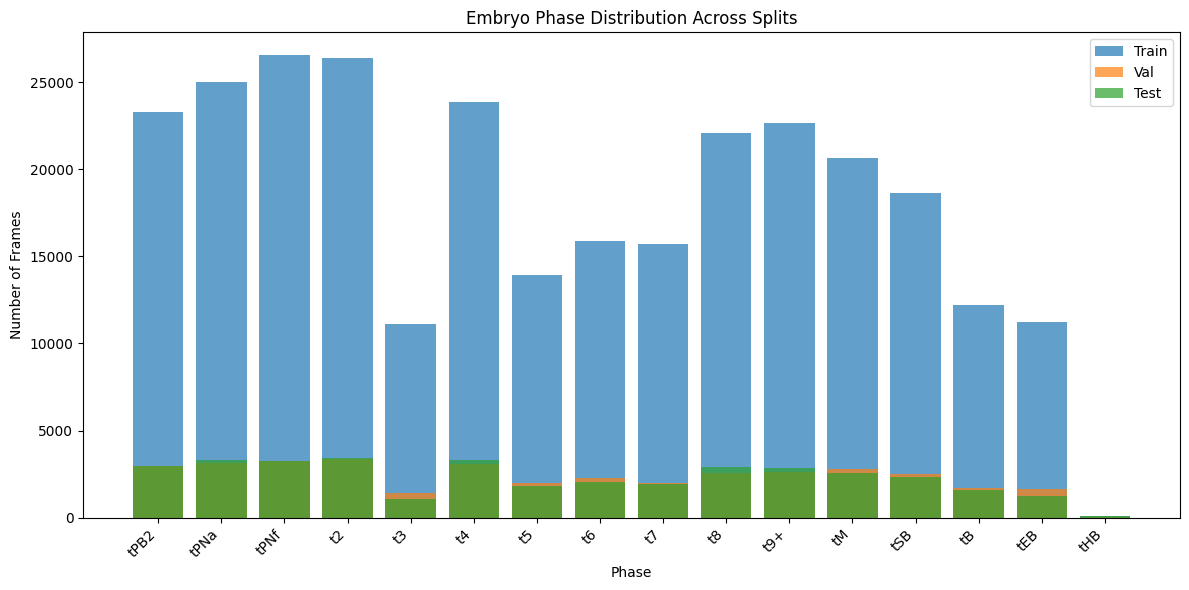

In [10]:
# 🧮 Class Distribution Visualization
from collections import Counter
import matplotlib.pyplot as plt

# Count samples per class
train_counts = Counter([lbl for _, lbl in train_ds.samples])
val_counts = Counter([lbl for _, lbl in val_ds.samples])
test_counts = Counter([lbl for _, lbl in test_ds.samples])

# Create a DataFrame for visualization
phase_names = [IDX2PHASE[i] for i in range(NUM_CLASSES)]
df_counts = pd.DataFrame({
    'Phase': phase_names,
    'Train': [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'Val': [val_counts.get(i, 0) for i in range(NUM_CLASSES)],
    'Test': [test_counts.get(i, 0) for i in range(NUM_CLASSES)]
})

display(df_counts)

# Plot distributions
plt.figure(figsize=(12, 6))
plt.bar(df_counts['Phase'], df_counts['Train'], label='Train', alpha=0.7)
plt.bar(df_counts['Phase'], df_counts['Val'], label='Val', alpha=0.7)
plt.bar(df_counts['Phase'], df_counts['Test'], label='Test', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Phase')
plt.ylabel('Number of Frames')
plt.title('Embryo Phase Distribution Across Splits')
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# 🧾 Embryo IDs per class (per split and overall)

from collections import defaultdict

def collect_embryo_ids_per_class(dataset):
    phase_to_ids = defaultdict(set)  # {label_idx: set(embryo_ids)}
    for path, lbl in dataset.samples:
        eid = path.parent.name  # folder name is the embryo id
        phase_to_ids[lbl].add(eid)
    return phase_to_ids

train_ids = collect_embryo_ids_per_class(train_ds)
val_ids   = collect_embryo_ids_per_class(val_ds)
test_ids  = collect_embryo_ids_per_class(test_ds)

# Build "overall" as the union across splits
overall_ids = defaultdict(set)
for i in range(NUM_CLASSES):
    overall_ids[i] = set().union(train_ids.get(i, set()),
                                 val_ids.get(i, set()),
                                 test_ids.get(i, set()))

def print_ids(title, mapping):
    print(f"\n=== {title} ===")
    for i, phase in enumerate(PHASES):
        ids = sorted(mapping.get(i, set()))
        print(f"{phase} [{len(ids)} embryos]: {', '.join(ids) if ids else '-'}")

#print_ids("TRAIN embryo IDs per class", train_ids)
#print_ids("VAL embryo IDs per class",   val_ids)
#print_ids("TEST embryo IDs per class",  test_ids)
#print_ids("OVERALL embryo IDs per class (union)", overall_ids)


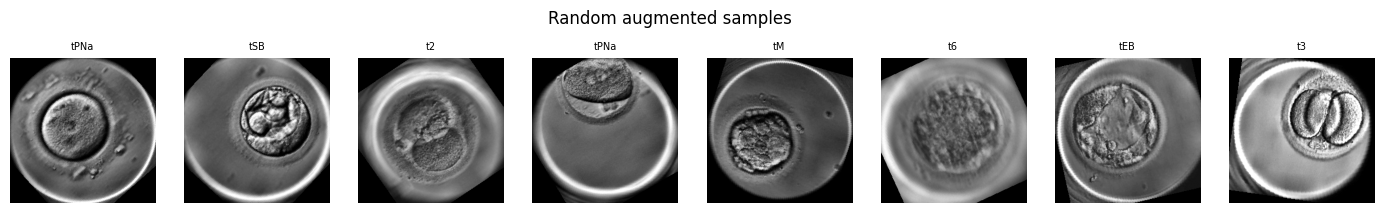

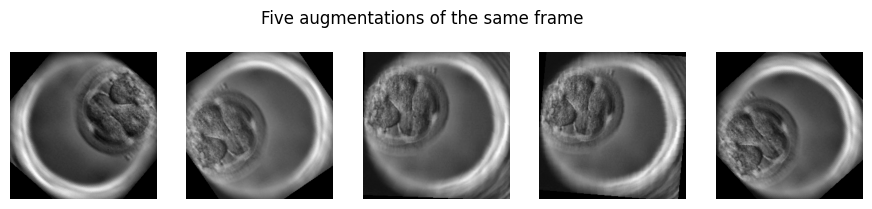

In [12]:
# @title 🔍 Preview data‐augmentations
import random, matplotlib.pyplot as plt
import torch

# -----------------------------------------------
# helper to de-normalise a 1×H×W tensor
def denorm(x):
    return (x*0.5 + 0.5).clamp(0,1).squeeze().cpu().numpy()

# 1)  Eight random augmented frames ----------------
N = 8
idxs = random.sample(range(len(train_ds)), N)
fig, axes = plt.subplots(1, N, figsize=(2.2*N, 2.5))

for ax, i in zip(axes, idxs):
    img, lbl = train_ds[i]
    ax.imshow(denorm(img), cmap='gray')
    ax.set_title(IDX2PHASE[lbl.item()], fontsize=7)
    ax.axis('off')
fig.suptitle("Random augmented samples", fontsize=12)
plt.show()

# 2)  Same frame, 5 different augmentations --------
idx = random.choice(range(len(train_ds)))
base_path, _ = train_ds.samples[idx]
base_img = Image.open(base_path).convert("L")

fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))
for ax in axes:
    aug = train_tfm(base_img)
    ax.imshow(denorm(aug), cmap='gray')
    ax.axis('off')
fig.suptitle("Five augmentations of the same frame", fontsize=12)
plt.show()


In [13]:
# @title 🧠 Model (noise-aware + timestep conditioning)
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int, max_period: float = 10000.0):
        super().__init__()
        self.dim = dim
        self.max_period = max_period
    def forward(self, t: torch.Tensor):
        # t: [B] int64 timesteps
        half = self.dim // 2
        t = t.float() / max(1, TIMESTEPS - 1)  # normalize to [0,1]
        freqs = torch.exp(
            -math.log(self.max_period) * torch.arange(0, half, device=t.device).float() / half
        )
        args = t[:, None] * freqs[None] * 2 * math.pi
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if self.dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
        return emb

class TimeCondEfficientNet(nn.Module):
    def __init__(self, n_classes: int, time_dim: int = 128):
        super().__init__()
        self.base = efficientnet_v2_s(weights=None)
        # Convert first layer to grayscale while preserving pre-trained weights
        old_conv = self.base.features[0][0]
        new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=3, stride=2, padding=1, bias=False)
        with torch.no_grad():
            new_conv.weight.data = old_conv.weight.data.sum(dim=1, keepdim=True) / 3.0
        self.base.features[0][0] = new_conv
        
        in_feats = self.base.classifier[1].in_features
        self.base.classifier = nn.Identity()
        
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_feats + time_dim, n_classes),
        )
    
    def forward(self, x: torch.Tensor, t: torch.Tensor):
        feats = self.base.features(x)
        feats = self.base.avgpool(feats)
        feats = torch.flatten(feats, 1)
        t_emb = self.time_mlp(self.time_embed(t))
        feats = torch.cat([feats, t_emb], dim=1)
        return self.classifier(feats)

n_classes = train_ds.num_classes
model = TimeCondEfficientNet(n_classes=n_classes, time_dim=128)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=2, min_lr=1e-7
)

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [14]:
MIXUP_ALPHA, MIXUP_PROB = 0.6, 0.0
def apply_mixup(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0 or x.size(0) < 2: return x, (y, None, 1.0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], (y, y[idx], lam)

In [15]:
EPOCHS = 1000
PATIENCE = 10  # Early stopping patience

# Mixed precision for speed
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

best_loss = float('inf')
best_state = None
epochs_no_improve = 0
loss_history = []

for epoch in range(1, EPOCHS+1):
    # --- train ---
    model.train()
    tr_loss = 0.0
    tr_hits = 0
    for xb, yb in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        do_mixup = np.random.rand() < MIXUP_PROB
        if do_mixup:
            xb, (y1, y2, lam) = apply_mixup(xb, yb)
        
        t = sample_timesteps(xb.size(0))
        xb_noisy, _ = q_sample(xb, t)
        with torch.autocast(device_type='cuda', enabled=use_amp):
            logits = model(xb_noisy, t)
            if do_mixup:
                loss = lam * criterion(logits, y1) + (1 - lam) * criterion(logits, y2)
            else:
                loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        tr_loss += loss.item() * xb.size(0)
        tr_hits += (logits.argmax(1) == yb).sum().item()
    tr_loss /= len(train_ds)
    tr_acc = tr_hits / len(train_ds)

    # --- val ---
    model.eval()
    val_loss = 0.0
    val_hits = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            t = sample_timesteps(xb.size(0))
            xb_noisy, _ = q_sample(xb, t)
            with torch.autocast(device_type='cuda', enabled=use_amp):
                logits = model(xb_noisy, t)
                loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            val_hits += (logits.argmax(1) == yb).sum().item()
    val_loss /= len(val_ds)
    val_acc = val_hits / len(val_ds)

    # Step scheduler after each batch in train loop
    scheduler.step(val_loss)
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"[{epoch:02d}] train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} | lr {curr_lr:.2e}")
    loss_history.append((tr_loss, val_loss))

    # --- early stop on val loss ---
    if val_loss < best_loss - 1e-6:
        best_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"\t*** New best! Val Loss: {val_loss:.4f} ***")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping after {epochs_no_improve} epochs.")
            break

# load best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

Epoch 1/1000: 100%|██████████| 9044/9044 [08:38<00:00, 17.45it/s]


[01] train loss 2.7791 acc 0.063 | val loss 2.7788 acc 0.070 | lr 3.00e-03
	*** New best! Val Loss: 2.7788 ***


Epoch 2/1000: 100%|██████████| 9044/9044 [07:53<00:00, 19.12it/s]


[02] train loss 2.6866 acc 0.100 | val loss 2.6023 acc 0.101 | lr 3.00e-03
	*** New best! Val Loss: 2.6023 ***


Epoch 3/1000: 100%|██████████| 9044/9044 [08:05<00:00, 18.62it/s]


...

[63] train loss 2.0089 acc 0.369 | val loss 2.1219 acc 0.323 | lr 4.03e-04


Epoch 64/1000: 100%|██████████| 9044/9044 [08:21<00:00, 18.05it/s]


[64] train loss 2.0084 acc 0.370 | val loss 2.1258 acc 0.320 | lr 3.22e-04


Epoch 65/1000: 100%|██████████| 9044/9044 [08:02<00:00, 18.75it/s]


[65] train loss 2.0051 acc 0.370 | val loss 2.1332 acc 0.316 | lr 3.22e-04

Early stopping after 10 epochs.


Test inference: 100%|██████████| 1145/1145 [00:23<00:00, 48.40it/s]
/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` para

              precision    recall  f1-score   support

        tPB2      0.613     0.803     0.695      2940
        tPNa      0.679     0.776     0.724      3283
        tPNf      0.653     0.551     0.598      3261
          t2      0.804     0.810     0.807      3395
          t3      0.391     0.557     0.459      1078
          t4      0.747     0.543     0.629      3282
          t5      0.383     0.403     0.393      1839
          t6      0.382     0.329     0.354      2030
          t7      0.342     0.379     0.360      1932
          t8      0.635     0.486     0.551      2919
         t9+      0.619     0.592     0.605      2870
          tM      0.587     0.760     0.662      2562
         tSB      0.654     0.497     0.565      2324
          tB      0.527     0.659     0.586      1561
         tEB      0.677     0.588     0.630      1260
         tHB      0.000     0.000     0.000        94

    accuracy                          0.600     36630
   macro avg      0.543   

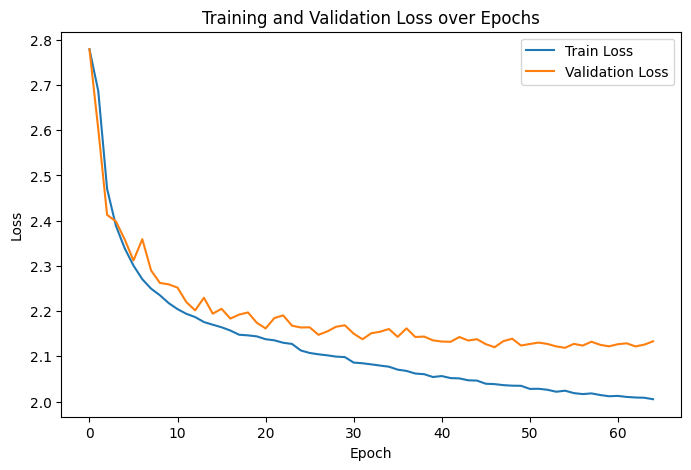

In [16]:
# @title 📊 Test‑Set Report
model.eval()
preds, trues = [], []
with torch.no_grad():
    for x, y in tqdm(test_dl, desc="Test inference"):
        x, y = x.to(device), y.to(device)
        t0 = torch.zeros(x.size(0), device=device, dtype=torch.long)
        logits = model(x, t0)
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(y.cpu().numpy())

# Get unique labels present in the test set
unique_labels = sorted(list(set(trues)))

# Filter and order target_names based on unique_labels
target_names = [IDX2PHASE[i] for i in sorted(set(trues))]


report = classification_report(trues, preds, labels=unique_labels, target_names=target_names, digits=3)
print(report)
cm = confusion_matrix(trues, preds, labels=unique_labels)
print("Confusion matrix\n", cm)

# loss history plot
train_losses, val_losses = zip(*loss_history)
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

In [17]:

# @title 💾 Save Model
import datetime, torch
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"embryo_phase_models/phase_classifier_{timestamp}.pth"
torch.save(model, out_path)
print("Model saved to", out_path)


Model saved to embryo_phase_models/phase_classifier_20260118_010706.pth
